# LGBM & XGBM

**1. Exploratory Data Analysis (EDA)**

In [ ]:
##importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.shape

(768, 9)

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.duplicated().sum()

np.int64(0)

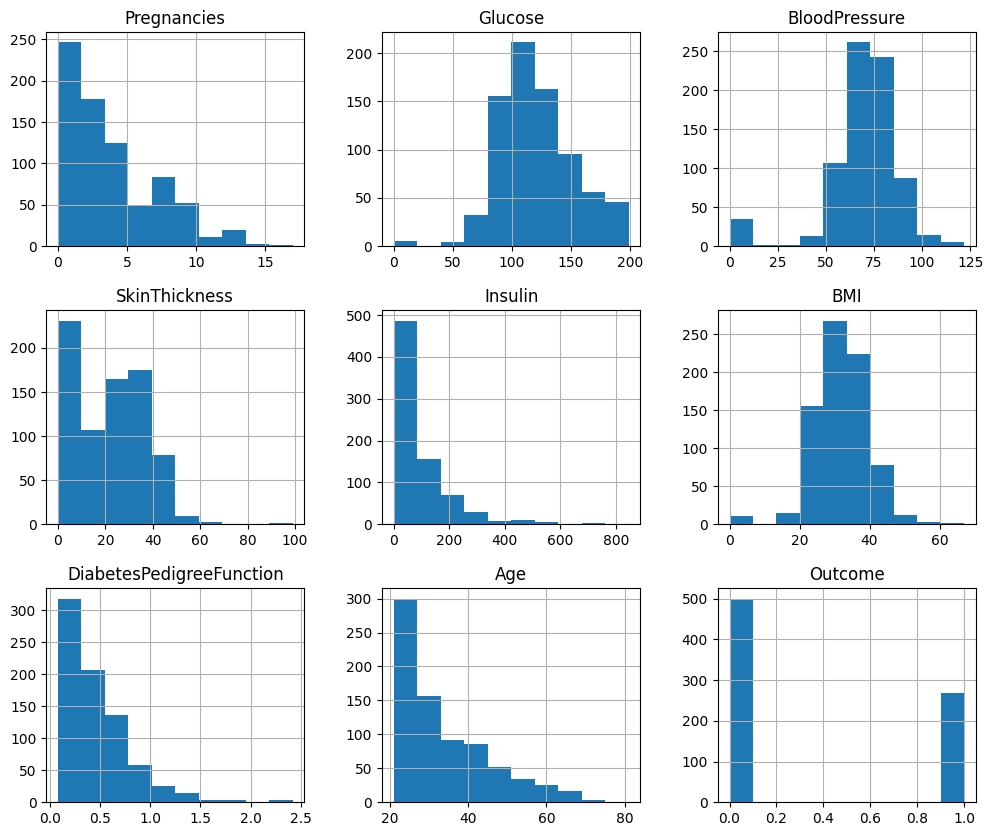

In [ ]:
#histogram
df.hist(figsize=(12,10))

plt.show()

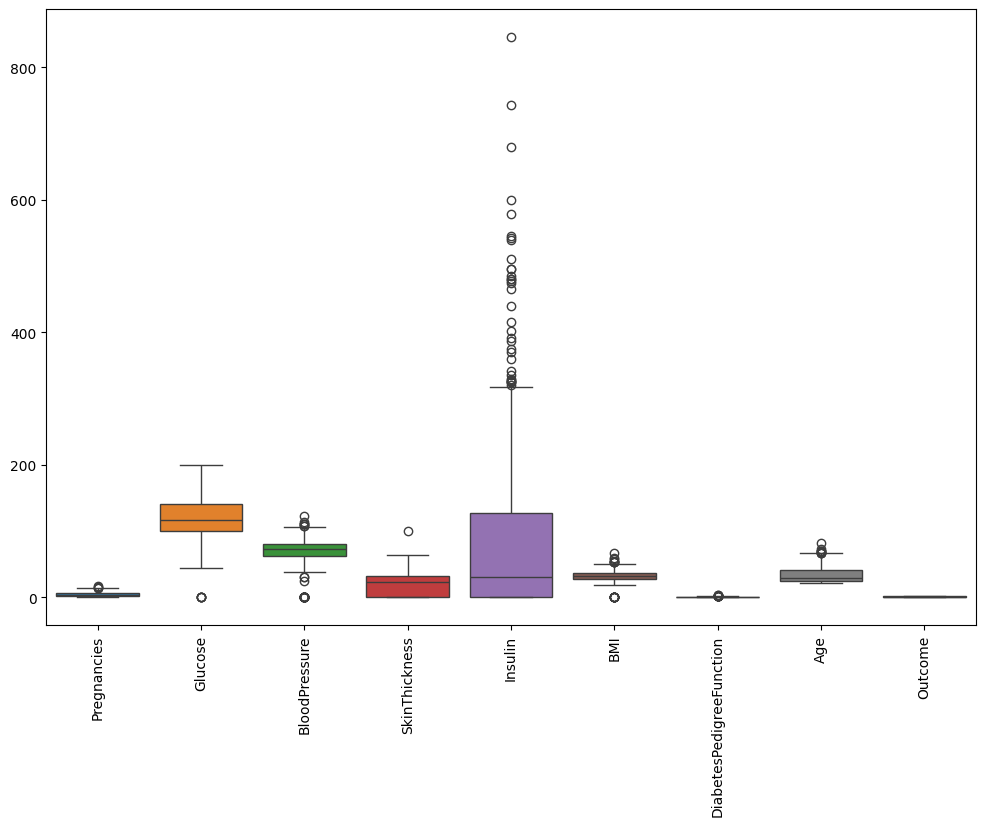

In [ ]:
#boxplot
plt.figure(figsize=(12,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

In [ ]:
#outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x:lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x )
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

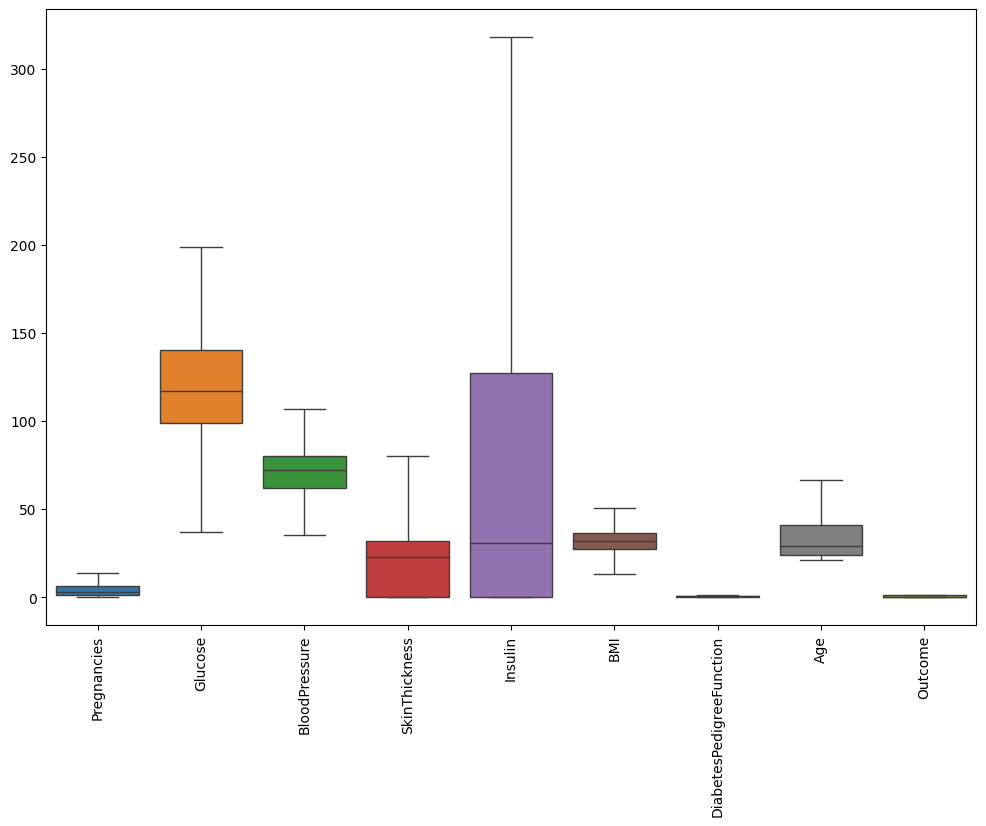

In [ ]:
plt.figure(figsize=(12,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

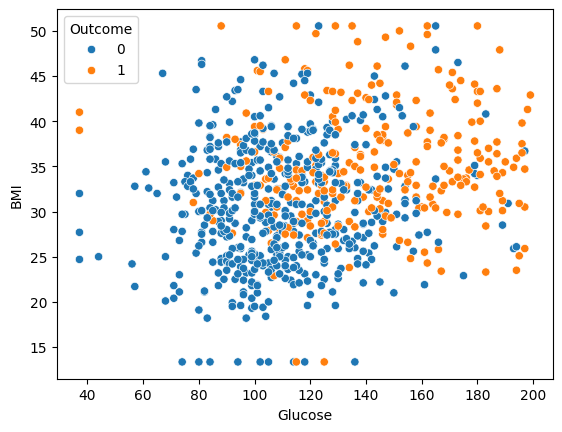

In [ ]:
#scater plot
sns.scatterplot(
    x='Glucose',
    y='BMI',
    hue='Outcome',
    data=df
)

plt.show()

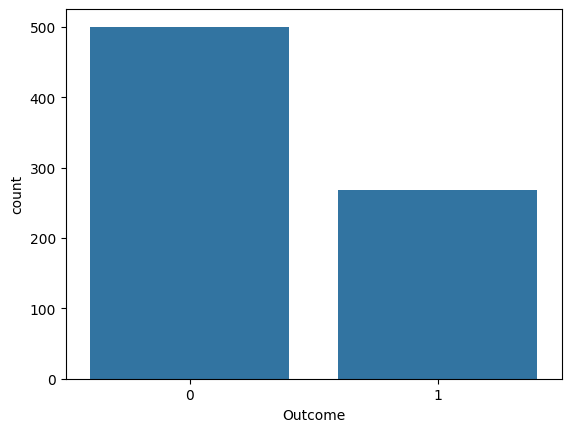

In [ ]:
#bar plot
sns.countplot(x='Outcome',data=df)

plt.show()

**2. Data Preprocessing**

In [ ]:
#Split Features and Target
X = df.drop("Outcome",axis=1)

y = df["Outcome"]

In [ ]:
#Train-Test Split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**3. Building Predictive Models**

In [ ]:
#LightGBM
lgbm = LGBMClassifier(random_state=42)

lgbm.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000193 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 652
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(random_state=42)

In [ ]:
#prediction
lgbm_pred = lgbm.predict(X_test)

In [ ]:
#XGBoost
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
#prediction
xgb_pred = xgb.predict(X_test)

**Cross Validation**

In [ ]:
#LightGBM
lgbm_cv = cross_val_score(
    lgbm,
    X,
    y,
    cv=5
)

print(lgbm_cv.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [ ]:
#XGBoost
xgb_cv = cross_val_score(
    xgb,
    X,
    y,
    cv=5
)

print(xgb_cv.mean())

0.7383244206773618


**Hyperparameter Tuning**

In [ ]:
#LightGBM
params = {

    'n_estimators':[50,100],

    'max_depth':[3,5,7]
}

grid = GridSearchCV(
    lgbm,
    params,
    cv=5
)

grid.fit(X_train,y_train)

print(grid.best_params_)

[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 571
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348269 -> initscore=-0.626657
[LightGBM] [Info] Start training from score -0.626657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [ ]:
#XGBoost - Hyperparameter Tuning
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=5
)

xgb_grid.fit(X_train, y_train)

print(xgb_grid.best_params_)

{'max_depth': 3, 'n_estimators': 50}


In [ ]:
# Retrain and evaluate using best tuned models
best_lgbm = grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

lgbm_pred_tuned = best_lgbm.predict(X_test)
xgb_pred_tuned = best_xgb.predict(X_test)

print("Tuned LightGBM Accuracy:", accuracy_score(y_test, lgbm_pred_tuned))
print("Tuned XGBoost Accuracy:", accuracy_score(y_test, xgb_pred_tuned))

Tuned LightGBM Accuracy: 0.7402597402597403
Tuned XGBoost Accuracy: 0.7077922077922078


**4. Model Evaluation**

In [ ]:
#LightGBM
print("Accuracy:",accuracy_score(y_test,lgbm_pred))

print("Precision:",precision_score(y_test,lgbm_pred))

print("Recall:",recall_score(y_test,lgbm_pred))

print("F1:",f1_score(y_test,lgbm_pred))

Accuracy: 0.7207792207792207
Precision: 0.5909090909090909
Recall: 0.7090909090909091
F1: 0.6446280991735537


In [ ]:
#XGBoost
print("Accuracy:",accuracy_score(y_test,xgb_pred))

print("Precision:",precision_score(y_test,xgb_pred))

print("Recall:",recall_score(y_test,xgb_pred))

print("F1:",f1_score(y_test,xgb_pred))

Accuracy: 0.7142857142857143
Precision: 0.5901639344262295
Recall: 0.6545454545454545
F1: 0.6206896551724138


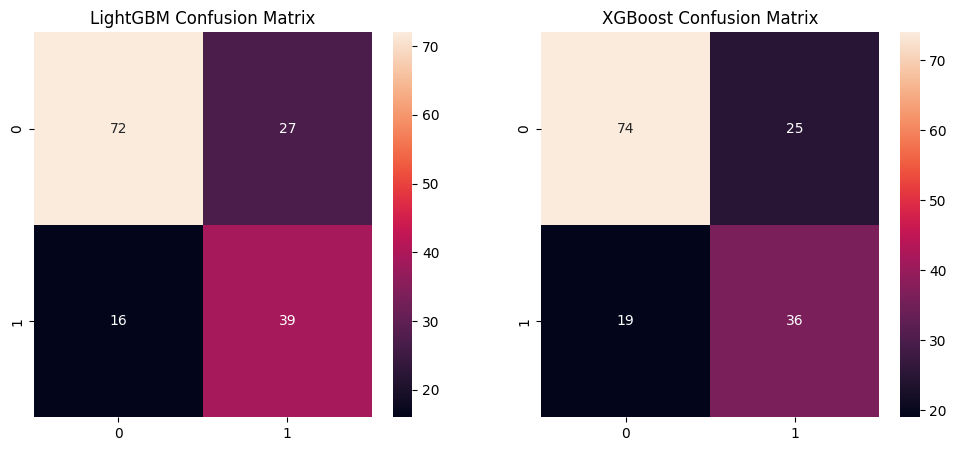

In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, lgbm_pred), annot=True, fmt='d', ax=axes[0])
axes[0].set_title("LightGBM Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', ax=axes[1])
axes[1].set_title("XGBoost Confusion Matrix")
plt.show()

**5. Comparative Analysis**

In [ ]:
comparison = pd.DataFrame({

    "Model":["LightGBM","XGBoost"],

    "Accuracy":[
        accuracy_score(y_test,lgbm_pred),
        accuracy_score(y_test,xgb_pred)
    ],

    "Precision":[
        precision_score(y_test,lgbm_pred),
        precision_score(y_test,xgb_pred)
    ],

    "Recall":[
        recall_score(y_test,lgbm_pred),
        recall_score(y_test,xgb_pred)
    ],

    "F1 Score":[
        f1_score(y_test,lgbm_pred),
        f1_score(y_test,xgb_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,LightGBM,0.720779,0.590909,0.709091,0.644628
1,XGBoost,0.714286,0.590164,0.654545,0.620690


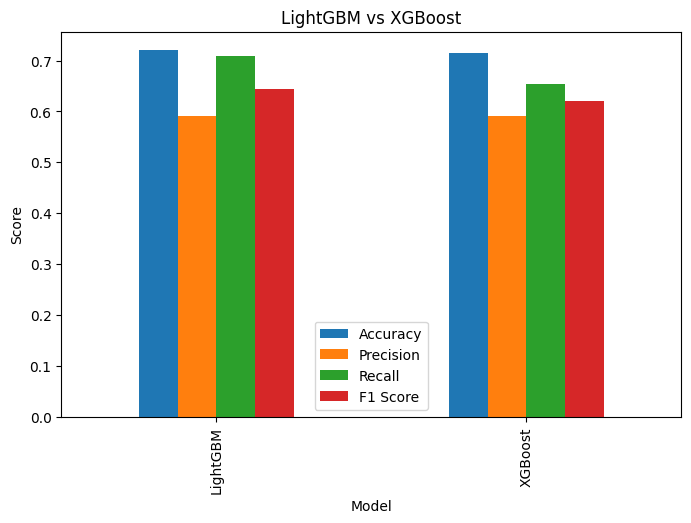

In [ ]:
#visualization
comparison.set_index("Model").plot(kind="bar",figsize=(8,5))

plt.ylabel("Score")

plt.title("LightGBM vs XGBoost")

plt.show()

## Final Report — Comparative Analysis

**Performance Summary**
- [Insert: which model had higher accuracy, and by how much]
- [Insert: which had higher recall — more important here, since missing a
  diabetic patient (false negative) is more costly than a false alarm]

**Cross-Validation Insight**
- LightGBM 5-fold CV accuracy: [insert lgbm_cv.mean() value]
- XGBoost 5-fold CV accuracy: [insert xgb_cv.mean() value]
- [Insert: did tuning improve scores compared to the default models?]

**Practical Implication**
- In a medical screening context, [insert better model] is preferred because
  [insert reasoning, e.g. higher recall = fewer missed diabetes cases]
- LightGBM is generally faster on larger datasets due to leaf-wise growth,
  while XGBoost tends to be more robust to overfitting on smaller datasets

**Limitations**
- Dataset is relatively small (768 rows) — results may not generalize well
- Zero-value imputation in Glucose/BMI/etc. used median replacement; more
  advanced imputation (e.g., KNN imputer) could be tested for further improvement